Convolutional Autoencoder Feature Extraction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

from sklearn.decomposition import PCA

In [3]:
PROCESSED_DIR = "/content/drive/MyDrive/sar-project/data/processed"

X_train = np.load(
    os.path.join(PROCESSED_DIR, "X_train.npy")
)

X_test = np.load(
    os.path.join(PROCESSED_DIR, "X_test.npy")
)

y_train = np.load(
    os.path.join(PROCESSED_DIR, "y_train.npy")
)

y_test = np.load(
    os.path.join(PROCESSED_DIR, "y_test.npy")
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (356, 128, 128, 1)
X_test : (90, 128, 128, 1)
y_train: (356,)
y_test : (90,)


In [6]:
#CHECKING FOR NANS
print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test :", np.isnan(X_test).sum())

NaN in X_train: 0
NaN in X_test : 0


In [7]:
#REMOVING NANS
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

print("NaNs removed")

NaNs removed


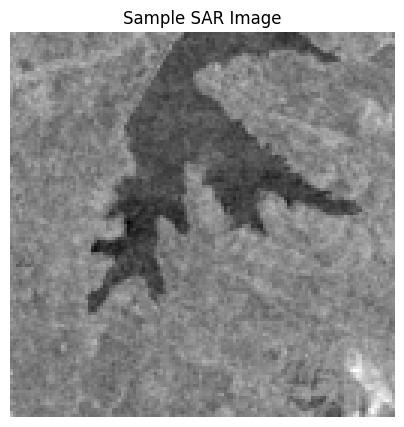

In [8]:
#VISUALIZING S SAMPLE IMAGE
plt.figure(figsize=(5,5))
plt.imshow(
    X_train[0].squeeze(),
    cmap="gray"
)
plt.title("Sample SAR Image")
plt.axis("off")
plt.show()

In [9]:
#BUILDING CONVULUTIONAL AUTOENCODER
input_img=Input(shape=(128,128,1))
x=Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x=MaxPooling2D((2,2),padding='same')(x)
x=Conv2D(16,(3,3),activation='relu',padding='same')(x)
encoded=MaxPooling2D((2,2),padding='same',name='latent_space')(x)

In [10]:
#DECODER
x=Conv2D(16,(3,3),activation='relu',padding='same')(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

In [11]:
#CREATE MODEL
autoencoder=Model(input_img,decoded)
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#TRAIN
history=autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=16,
    validation_data=(X_test,X_test)
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 723ms/step - loss: 0.0394 - val_loss: 0.0493
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 708ms/step - loss: 0.0308 - val_loss: 0.0207
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 844ms/step - loss: 0.0068 - val_loss: 0.0035
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 759ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 697ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 772ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 752ms/step - loss: 0.0027 - val_loss: 0.0022
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 787ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 732ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 725ms/step - loss: 0.0023 - val_loss: 0.0020


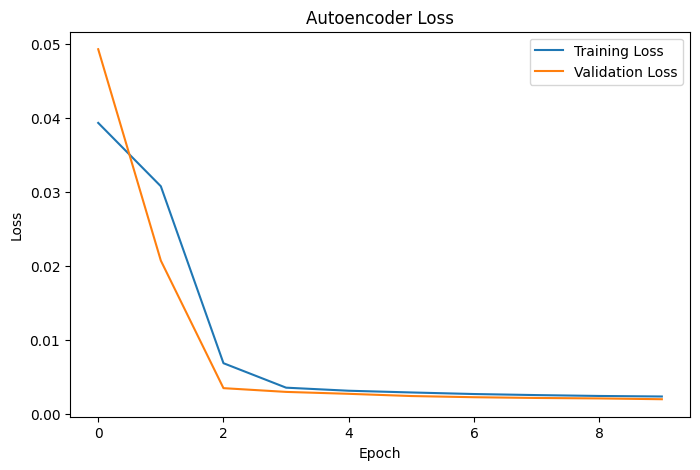

In [13]:
#PLOT TRAINING LOSS
plt.figure(figsize=(8,5))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Loss")

plt.legend()
plt.show()

In [14]:
#RECONSTRUCTION
reconstructed = autoencoder.predict(
    X_test[:5]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


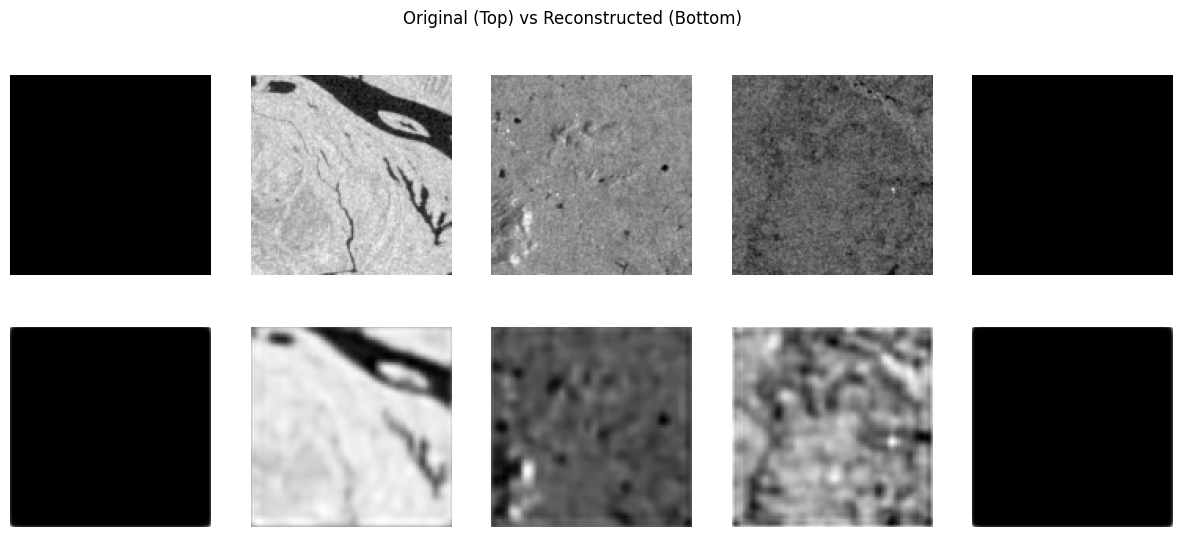

In [16]:
#EXAMPLE
n = 5

plt.figure(figsize=(15,6))

for i in range(n):

    plt.subplot(2,n,i+1)

    plt.imshow(
        X_test[i].squeeze(),
        cmap='gray'
    )

    plt.axis('off')

    plt.subplot(2,n,i+1+n)

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle(
    "Original (Top) vs Reconstructed (Bottom)"
)

plt.show()

In [17]:
#FEATURE EXTRACTION
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer(
        "latent_space"
    ).output
)

latent_features = encoder.predict(
    X_train
)

print(latent_features.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
(356, 32, 32, 16)


In [18]:
latent_flat = latent_features.reshape(
    latent_features.shape[0],
    -1
)

print(latent_flat.shape)

(356, 16384)


In [19]:
#PCA VISUALISATION
pca = PCA(n_components=2)
pca_features = pca.fit_transform(
    latent_flat
)
print(pca_features.shape)

(356, 2)


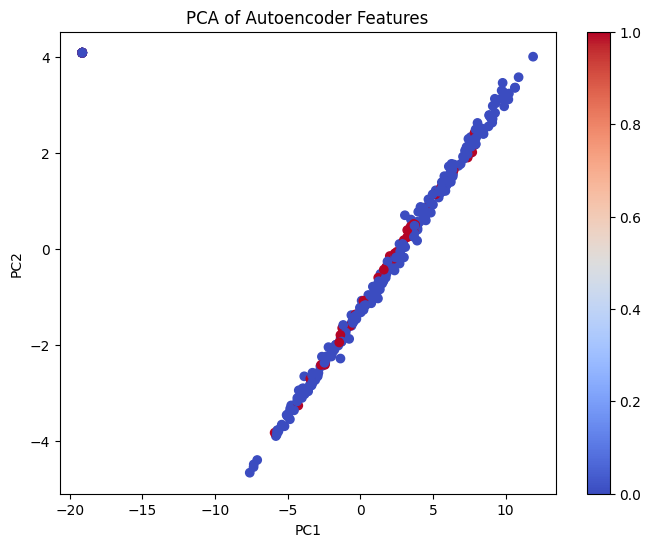

In [20]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=y_train,
    cmap='coolwarm'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Autoencoder Features")

plt.colorbar(scatter)
plt.show()

In [21]:
#SAVING EXTRACTED FEATURES
FEATURE_DIR = "/content/drive/MyDrive/sar-project/data/features"

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

In [22]:
np.save(
    os.path.join(
        FEATURE_DIR,
        "latent_features.npy"
    ),
    latent_flat
)
print("Features Saved")

Features Saved
